In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [11]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

In [12]:
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

In [13]:
model = keras.Sequential(
    [
        keras.layers.Embedding(10000, 128, input_length=200),
        keras.layers.Bidirectional(
            keras.layers.LSTM(20)
        ),
        keras.layers.Dense(20, activation='relu'),
        keras.layers.Dense(2, activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=4
)

Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.9126 - loss: 0.2243 - val_accuracy: 0.8732 - val_loss: 0.3479
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 116s 165ms/step - accuracy: 0.9439 - loss: 0.1515 - val_accuracy: 0.8672 - val_loss: 0.3572
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 162ms/step - accuracy: 0.9684 - loss: 0.0892 - val_accuracy: 0.8716 - val_loss: 0.4375
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 167ms/step - accuracy: 0.9772 - loss: 0.0635 - val_accuracy: 0.8212 - val_loss: 0.7445


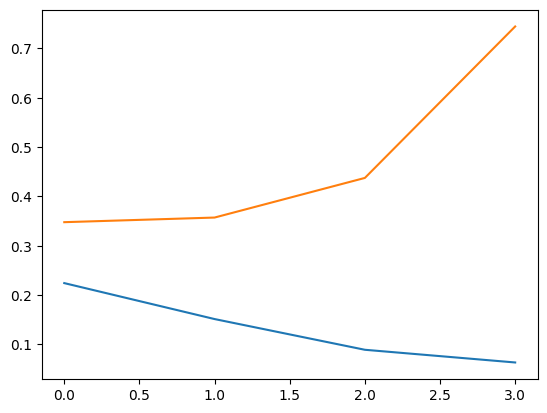

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

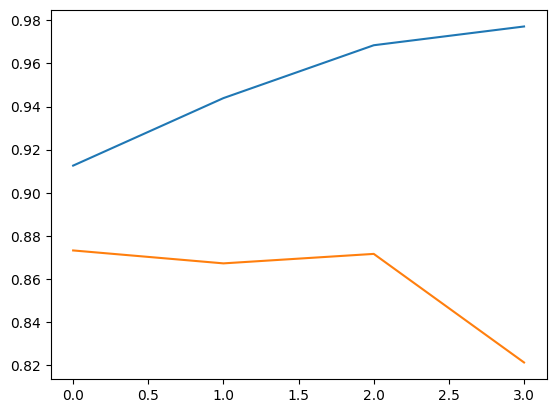

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [20]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

word_index = imdb.get_word_index()

text = "this movie is very good"

words = text.lower().split()

encoded = []

for word in words:
    if word in word_index and word_index[word] < 10000:
        encoded.append(word_index[word])

padded = pad_sequences([encoded], maxlen=200)

prediction = model.predict(padded)

print(prediction)

if prediction[0][0] > prediction[0][1]:
    print("Negative Review")
else:
    print("Positive Review")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
[[0.20736763 0.79263234]]
Positive Review
